# Pràctica de Regressió Logística amb la base de dades "South African Heart Disease Data".
## Objectius de la pràctica:
1. Treballar amb  la base de dades South African Heart Disease Data.
   * #### Suposarem que és un problema que ens han encarregat resoldre i proporcionarem:
    1. Propietats de les  variables observades i com es relacionen amb el la presència de malaltia coronaria.
    2. Explicació de com les variables observades afecten la presència de malaltia coronaria.
    3. Crearem un indicador probabilistic de la presència de malaltia coronaria.
3. Aprendre a interpretar la geometria de la regressió logística.
4. Crear un sistema de diagnóstic.


## 1. Descripció del problema:

**Objectiu**
Proporcionar un indicador probabilistic de la presència de malaltia coronaria, i una explicació de la importància dels factors que afecten.

**Descripció de la base de dades "South African Heart Disease Data".**

Un estudi retrospectiu es va dur a terme entre homes d'una regió de risc alt de malalties cardíaques al Cap Occidental, Sud-àfrica. Es van incloure aproximadament dos controls per cada cas de malaltia coronària (CHD). Molts dels homes amb CHD havien rebut tractaments per reduir la pressió arterial i altres programes per disminuir els factors de risc després d'haver patit un episodi de CHD, i en alguns casos, les mesures es van prendre després d'aquests tractaments.

Aquestes dades provenen de l'estudi original (amb algunes modificacions com convertir la variable chd en un factor) i estan basades en el paquet ElemStatLearn de 2015, ara arxivat.

A finals dels anys 70, es va observar una alta incidència de malaltia isquèmica cardíaca entre homes blancs, afrikaans-parlants, al sud-oest del Cap (Wyndham, 1982). L'any 1979, Rossouw et al. (1983) van reclutar uns 8.200 habitants (3.357 homes blancs i 3.831 dones blanques) de tres comunitats afrikaner mitjançant una campanya intensiva per correu. Es va determinar la presència o absència de CHD per a cada participant (inicialment com a "1" per als casos i "0" per als controls; actualment com a "Yes" o "No"), juntament amb diversos factors de risc coneguts.

L'objectiu era analitzar la prevalença i intensitat dels factors de risc de CHD en aquestes comunitats, amb especial atenció als factors de risc majors que es podrien considerar reversibles, com la hipercolesterolèmia, la hipertensió i el tabaquisme (Rossouw et al., 1983).

Hastie i Tibshirani (1987) van seleccionar un subgrup de 465 homes dels 3.357 inicials. Aquest grup incloïa 162 casos de CHD i 303 controls. Tot i això, les dades utilitzades actualment contenen informació sobre 462 subjectes (160 casos i 302 controls), probablement per discrepàncies en els registres. Aquestes dades també es van utilitzar en treballs posteriors de Hastie, Tibshirani i Friedman (2009).

**Bibliografia**

1. Hastie, T., & Tibshirani, R. (1987). Non-parametric logistic and proportional odds regression. Journal of the Royal Statistical Society: Series C (Applied Statistics), 36(3), 260-276.
2. Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning, 2nd Edition. Springer New York. doi:10.1007/978-0-387-84858-7
3. Rossouw, J. E., Plessis, J. P. D., Benad\'e, A. J. S., Jordaan, P. C. J., Kotz\'e, J. P., Jooste, P. L., & Ferreira, J. J. (1983). Coronary risk factor screening in three rural communities: The CORIS baseline study. South African Medical Journal, 64, 430-436.
4. Wyndham, C. (1982). Trends with time of cardiovascular mortality rates in the populations of the RSA for the period 1968-1977. South African Medical Journal, 61, 987-993.


### <font color="blue"><b>1.1. Variables de la base de dades</b></font> 
### La base de dades té de 462 registres i 10 variables.

| Característica | Descripció |
|---|---|
| bp | Pressió sanguínia sistòlica |
| tobacco | Tabac acumulat (kg) |
| ldl | Nivell de colesterol LDL (lipoproteïna de baixa densitat) |
| adiposity | Sobrepès sever (vector numèric) |
| famhist | Historial familiar de malalties del cor |
| typea | Comportament tipus A |
| obesity | Acumulació excessiva de greix (vector numèric) |
| alcohol | Consum actual d'alcohol |
| age | Edat a l'inici |
| chd | Resposta, malaltia coronària del cor |


### <font color="blue"><b>1.2. Explicació de les variables</b></font> 


##### **a) Pressió Sanguínia Sistòlica (sbp)**

La pressió sanguínia sistòlica alta és un factor de risc important per a les malalties cardíaques. Un valor elevat de pressió sistòlica pot causar danys als vasos sanguinis, augmentant les probabilitats de formació de placa, arteriosclerosi, i per tant, augmentant el risc de malalties coronàries i atacs de cor.

##### **b) Nivell de Colesterol LDL (ldl)**

El colesterol LDL, conegut com el "colesterol dolent", quan està elevat, contribueix a la formació de placa a les artèries. Aquesta placa pot reduir el flux sanguini cap al cor, augmentant el risc d'infart de miocardi o altres malalties coronàries.

##### **c) Historial Familiar (famhist)**

Un historial familiar de malalties cardíaques (famhist) indica que hi ha una predisposició genètica. Si hi ha antecedents de malalties cardíaques en la família, especialment en pares o germans, això augmenta el risc personal d'experimentar malalties similars, ja que poden heretar-se factors genètics que afavoreixen aquestes condicions.

##### **d) Comportament de Tipus A**

El comportament de tipus A, denotat com **typea** en el conjunt de dades, es refereix a un patró de comportament que es considera un factor de risc per a la malaltia coronària. Aquest comportament està caracteritzat per:
- Ambició intensa
- Impaciència
- Competitivitat
- Tendència a la hostilitat 
- Pressió per acomplir moltes coses en poc temps

Les persones amb aquest tipus de comportament poden experimentar més estrès, el qual està lligat a un major risc de malalties cardíaques.
##### **e) Diferència entre obesitat i adipositat:**

| Característica | **Obesitat (Índex de Massa Corporal)** | **Adipositat (Percentatge de Greix)** |
| :--- | :--- | :--- |
| **Definició** | Un indicador de la "pesantor" corporal que relaciona el pes total amb l'alçada. | El percentatge real de la massa total del cos compost per teixit adipós (greix). |
| **Fórmula / Càlcul** | $$IMC = \frac{\text{pes en kg}}{\text{(alçada en m)}^2}$$ | Estimació mitjançant fórmules (com Durnin-Womersley) basades en plecs cutanis. |
| **Mètode de Mesura** | Bàscula i tallímetre (estadiòmetre). | **Adipòmetre o calibrador**: mesura del gruix del greix subcutani en punts clau. |
| **Punts de Mesura** | Pes total i alçada total. | Tríceps, zona subescapular i zona suprailíaca. |
| **Criteri Clínic** | En l'estudi de 1983, un **IMC de 30 o superior** classificava el participant com a "obès". | Mesura directa de la concentració de teixit grasso, independent del pes muscular. |
| **Limitació** | No distingeix entre la massa muscular i la massa grassa (un atleta pot tenir un IMC alt sense ser obès). | Requereix personal entrenat per fer les mesures manuals amb precisió. |

### **Definició de Malaltia Cardíaca Coronària (CHD)**

La **Malaltia Cardíaca Coronària** (CHD) és una condició en què es redueix o bloqueja el flux sanguini als músculs del cor, generalment a causa de l'acumulació de placa a les artèries coronàries. Això pot portar a angina de pit, infarts de miocardi o fins i tot mort sobtada. Els símptomes poden incloure dolor o malestar al pit, dificultat per respirar, i en casos greus, col·lapse cardíac.

## <font color="red"><b>Exercici 1</b></font>
1. Per tal de clarificar els objectius d'aquesta pràctica, redactar un paràgraf resumint el tipus de base de dades utilitzada i l'objectiu de la pràctica.
2. Abans d'aplicar mètodes d'Intel.ligència artificial, cal tenir una intuició sobre com influencien les variables observacionals  el resultat. A partir de la descripció de les variables escrigui breument la llista de variables que poden agumentar o disminuir el temps de supervivència. Redactar  una explicació d'una línia per justificar cada cas.

## 2.0. Regressió Logística: Una Introducció Intuïtiva

- Volem una variable indicadora cdh ={+1,-1} que digui presència o ausència:
    -  **Fórmula de la Regressió Logística**:
      $ chd = f( X_1 , X_2 + \ldots ,X_n ) $

        On:
        - $f(.)$ és binaria.
### 2.1. Hipotesi sobre la distribucio de la Variable CHD (*malaltia coronària del cor*) en funció d'altres variables.


#### &nbsp; &nbsp; **Probabilitat condicionada:**
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; P(chd =1/{alcohol, edat}) i &nbsp;&nbsp; P(chd =0/{alcohol, edat})

  
<img src="gaussian_contour_plot.png" alt="Dues distribucions gausianes" width="700" /> 

<img src="gaussian_contour_plot_3D.png" alt="Dues distribucions gausianes en 3D" width="600"/>

## Explicació
1. **Distribucions Gaussianes P(chd =1/{alcohol, edat}) i P(chd =0/{alcohol, edat})**:
   - Es defineixen dos grups de població:
     - **Grup 1**: Representa individus amb **chd = 1** (presència de malaltia coronària). S'assigna una gaussiana amb mitjana `m1 = [1, 1]`, on 1 en alcohol i 1 en edat podrien indicar nivells moderats d'alcohol i una certa edat que es relacionen amb un risc major de CHD.
     - **Grup 2**: Representa individus amb **chd = 0** (absència de malaltia coronària). S'assigna una gaussiana amb mitjana `m2 = [-1, -1]`, suggerint nivells més baixos d'alcohol i edat que es correlacionen amb menys risc de CHD.

2. **Paràmetres**:
   - **Mitjanes (m1 i m2)**: La mitjana controla on es concentra la major densitat de probabilitat per a cada grup en l'espai bidimensional d'alcohol i edat.
   - **Matriu de covariància (s)**: La mateixa per a ambdues distribucions, suggerint que la variabilitat i la correlació entre alcohol i edat és similar en ambdues poblacions.
3. **Figura**:
   - Es fan servir <u></u>línies de contorn per mostrar les densitats de probabilitat de les distribucions gaussianes en un pla bidimensional, amb:
     - **Verd** per a la distribució amb CHD, indicant on és més probable trobar individus amb malaltia coronària.
     - **Vermell** per a la distribució sense CHD, indicant on és més probable trobar individus sans en aquest context.

4. **Interpretació de les Gràfiques**:
   - La gràfica de l'esquerra (amb mitjana [1,1]) podria suggerir que individus amb un consum moderat d'alcohol i una edat avançada tenen un risc elevat de CHD.
   - La gràfica de la dreta (amb mitjana [-1,-1]) podria indicar que menys consum d'alcohol i menys edat s'associen amb menys probabilitat de CHD.

Aquest model simplifica la realitat molt; en la pràctica, CHD està influenciada per molts més factors que només alcohol i edat. Així, aquest exemple serveix més com una il·lustració conceptual de com podríem modelar hipòtesis sobre la distribució de poblacions en relació amb una malaltia, usant estadístiques.

#### Funció que indica la certesa P(chd =1/{alcohol, edat}).

###### Observar que: $P(chd =0/{alcohol, edat}) = 1- P(chd =1/{alcohol, edat})$ 

5. **Esquerra:** Observar encavalcament entre distribucions, i <u>recta que passa per la regió d'igual probabilitat</u>

   **Dreta:** Funció que indica probabilitat de chd =1 $P(\text{chd} = 1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 \cdot \text{Alcohol} + \beta_2 \cdot \text{Edat})}}$
  
<img src="LlocGeometric.png" alt="Dues distribucions gausianes" width="400"/> <img src="Logistica.png" alt="Logistica" width="500"/>

6. **Representació de les regions d'igual probabilitat vs funció logistica.**
<img src="FronteraDecisio.png" alt="Dues distribucions gausianes" width="600"/> <img src="3D_decision_boundary.png" alt="Logistica" width="500"/>


## <font color="red"><b>Exercici 2</b></font>
1. Per tal de clarificar els conceptes, faci un resum d'un paràgraf amb diagrames explicant les idees anteriors.


### 2.2. Definició formal de la regressió logística

La regressió logística és un mètode estadístic per predir classes binàries. La variable objectiu o d'outcome és binària, és a dir, només hi ha dos resultats possibles. Per exemple, en proves mèdiques, el resultat pot ser "risc de chd" o "ausència de risc".

El model de regressió logística estima les probabilitats que una observació pertanyi a una de les dues classes. La probabilitat del resultat es modela com una funció d'una combinació lineal de variables explicatives,  es a dir: $cdh = f(\beta_0 + \beta_1 \cdot \text{Alcohol} + \beta_2 \cdot \text{Edat})$

La funció logística $f()$, també anomenada funció sigmoide, i.e. $\frac{1}{1 + e^{-x}}$, s'utilitza per modelar la probabilitat de la classe per defecte. 
* La regressió logística té la següent fórmula:

$$P(Y = 1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_n X_n)}}$$

On:

- $ P(Y = 1) $ és la probabilitat que es produeixi l'esdeveniment.
- $ e $ és la base dels logaritmes naturals.
- $ \beta_0 $ és el terme de risc base, en ausència d'observacions.
- $ \beta_1, \beta_2, \ldots, \beta_n $ són els coeficients per a les variables explicatives $ X_1, X_2, \ldots, X_n $.


# 3. Part pràctica.

* ###  Primer carreguem les llibreries de python 
* ###  Desprès carreguem la base de dades

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D

#### Lectura de la base de dades.

In [28]:
file_path = 'SAHeart.csv'
heart_data = pd.read_csv(file_path)

# Visualització les primeres mostres del conjunt de dades

heart_data.drop(columns = ['row.names'],inplace = True)
heart_data.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


#### Fem una inspecció de la base de dades, i mirem si hem de corregir algun format de dades.

In [29]:
print('\n Columnes/variables\n ','_'*40)
print(list(heart_data.columns))
print('\n \n Tipus de dades de  les Columnes/variables\n ','_'*40)
print(heart_data.info())


 Columnes/variables
  ________________________________________
['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age', 'chd']

 
 Tipus de dades de  les Columnes/variables
  ________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 36.2+ KB
None


####  Veurem valors de la variable categòrica

In [30]:
print('\n \n Valors de la variable categorica, "family history"\n ','_'*40)
print(heart_data.famhist.unique())


 
 Valors de la variable categorica, "family history"
  ________________________________________
['Present' 'Absent']


### Corregim les dades que no són float i el codi de "famhist".

In [31]:
# Transformem 'famhist' en una variable binària
# Aquí 'Present' es converteix en 1 i 'Absent' en 0
heart_data['famhist'] = heart_data['famhist'].map({'Present': 1, 'Absent': 0})

# Convertim 'typea', 'age' i 'chd' en tipus float
# Això assegura que les columnes siguin tractades com a nombres de coma flotant
heart_data['typea'] = heart_data['typea'].astype(float)
heart_data['age'] = heart_data['age'].astype(float)
heart_data['chd'] = heart_data['chd'].astype(float)

# Mostrem les primeres files per verificar els canvis
heart_data.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,1,49.0,25.30,97.20,52.0,1.0
1,144,0.01,4.41,28.61,0,55.0,28.87,2.06,63.0,1.0
2,118,0.08,3.48,32.28,1,52.0,29.14,3.81,46.0,0.0
3,170,7.50,6.41,38.03,1,51.0,31.99,24.26,58.0,1.0
4,134,13.60,3.50,27.78,1,60.0,25.99,57.34,49.0,1.0


## <font color="red"><b>Exercici 3</b></font>
1. Expliqui breument el que fa els mètodes "map" i "astype"

### Estadístiques descriptives per a les columnes numèriques

In [32]:
# Estadístiques descriptives per a les columnes numèriques
heart_data.describe().round(2)

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
count,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00
mean,138.33,3.64,4.74,25.41,0.42,53.10,26.04,17.04,42.82,0.35
std,20.50,4.59,2.07,7.78,0.49,9.82,4.21,24.48,14.61,0.48
min,101.00,0.00,0.98,6.74,0.00,13.00,14.70,0.00,15.00,0.00
25%,124.00,0.05,3.28,19.77,0.00,47.00,22.98,0.51,31.00,0.00
50%,134.00,2.00,4.34,26.12,0.00,53.00,25.80,7.51,45.00,0.00
75%,148.00,5.50,5.79,31.23,1.00,60.00,28.50,23.89,55.00,1.00
max,218.00,31.20,15.33,42.49,1.00,78.00,46.58,147.19,64.00,1.00


## <font color="red"><b>Exercici 4</b></font>
1.  Observar que la mitjana aritmètica i mediana (percentil 50%) d'algunes variables són diferents, i les desviacions estandard són molt semblants a les mitjanes. Es coherent amb una distribució Gausiana?, Quina distribució estadística coneix que tingui aquesta propietat?

* **Atenció**: aquest apartat servirà per interpretar mes endavant la figura: Box Plot (diagrama en capces).

## 3.1 **Recordatori:** Anàlisi Exploratòria de Dades (EDA)

* **Estadístics Descriptiu:**
    * **Mitjana:** $\bar{X} = \frac{1}{n}\sum_{i=1}^{n}X_i$
    * **Mediana:** El valor del mig (percentil 50%) quan les dades estan ordenades.
    * **Moda:** El valor més freqüent.
    * **Desviació Estàndard:** $\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(X_i - \bar{X})^2}$
    * **Quartils:** Valors que divideixen les dades en els valors per sota un percentil (min, 25%,50%,75%).
        * **Q1:** Percentil 25
        * **Q2:** Percentil 50 (mediana)
        * **Q3:** Percentil 75
    * **Rang Interquartílic (IQR):** Q3 - Q1
* **Quantils**

    * Els quantils són punts de tall que divideixen l'abast d'una distribució de probabilitat en intervals continus amb probabilitats iguals. Hi ha diversos tipus de quantils, però els més comuns són els quartils (que divideixen les dades en quarts).
    
    El k-èsim quantil es pot calcular amb la fórmula: $Q_k = \frac{k(N + 1)}{4}$
    
    per a $ k = 1, 2, \ldots, N $ on $ Q_k $ és el k-èsim quantil i $ N $ és el nombre d'observacions.
 
### Figures

* **Histograma:** Una representació gràfica de la distribució d'una variable numèrica. Mostra la freqüència d'aparició de diferents valors dins de rangs especificats.
* **Diagrama de Caixes (Box Plot):** Una manera estandarditzada de mostrar dades basada en un resum de cinc valors descriptius: mínim, primer quartil (Q1), mediana (Q2), tercer quartil (Q3) i màxim. Els diagrames de caixes són útils per identificar valors atípics i comparar distribucions.


**Recordar** que EDA és important per a  <font color="Blue"><b>l'informe Final i Recomanacions</b></font> que es presenten al final dels estudis.

## 3.2.1 Histograma (distribució de prob.).
* Nota: fem servir la llibria "seaborn" (https://seaborn.pydata.org/examples
* ## Histograma

    * Un histograma és una representació aproximada de la distribució de dades numèriques. Va ser introduït per primera vegada per Karl Pearson. Per construir un histograma, el primer pas és "classificar" l'abast dels valors, és a dir, dividir l'abast complet dels valors en una sèrie d'intervals, i després comptar quants valors cauen en cada interval.
    
    * **Definició formal Histograma:**  $\sum_{i=1}^{n} f(x_i)$
    
    on $ f(x_i) $ és la freqüència d'aparició del valor $ x_i $ en el conjunt de dades.

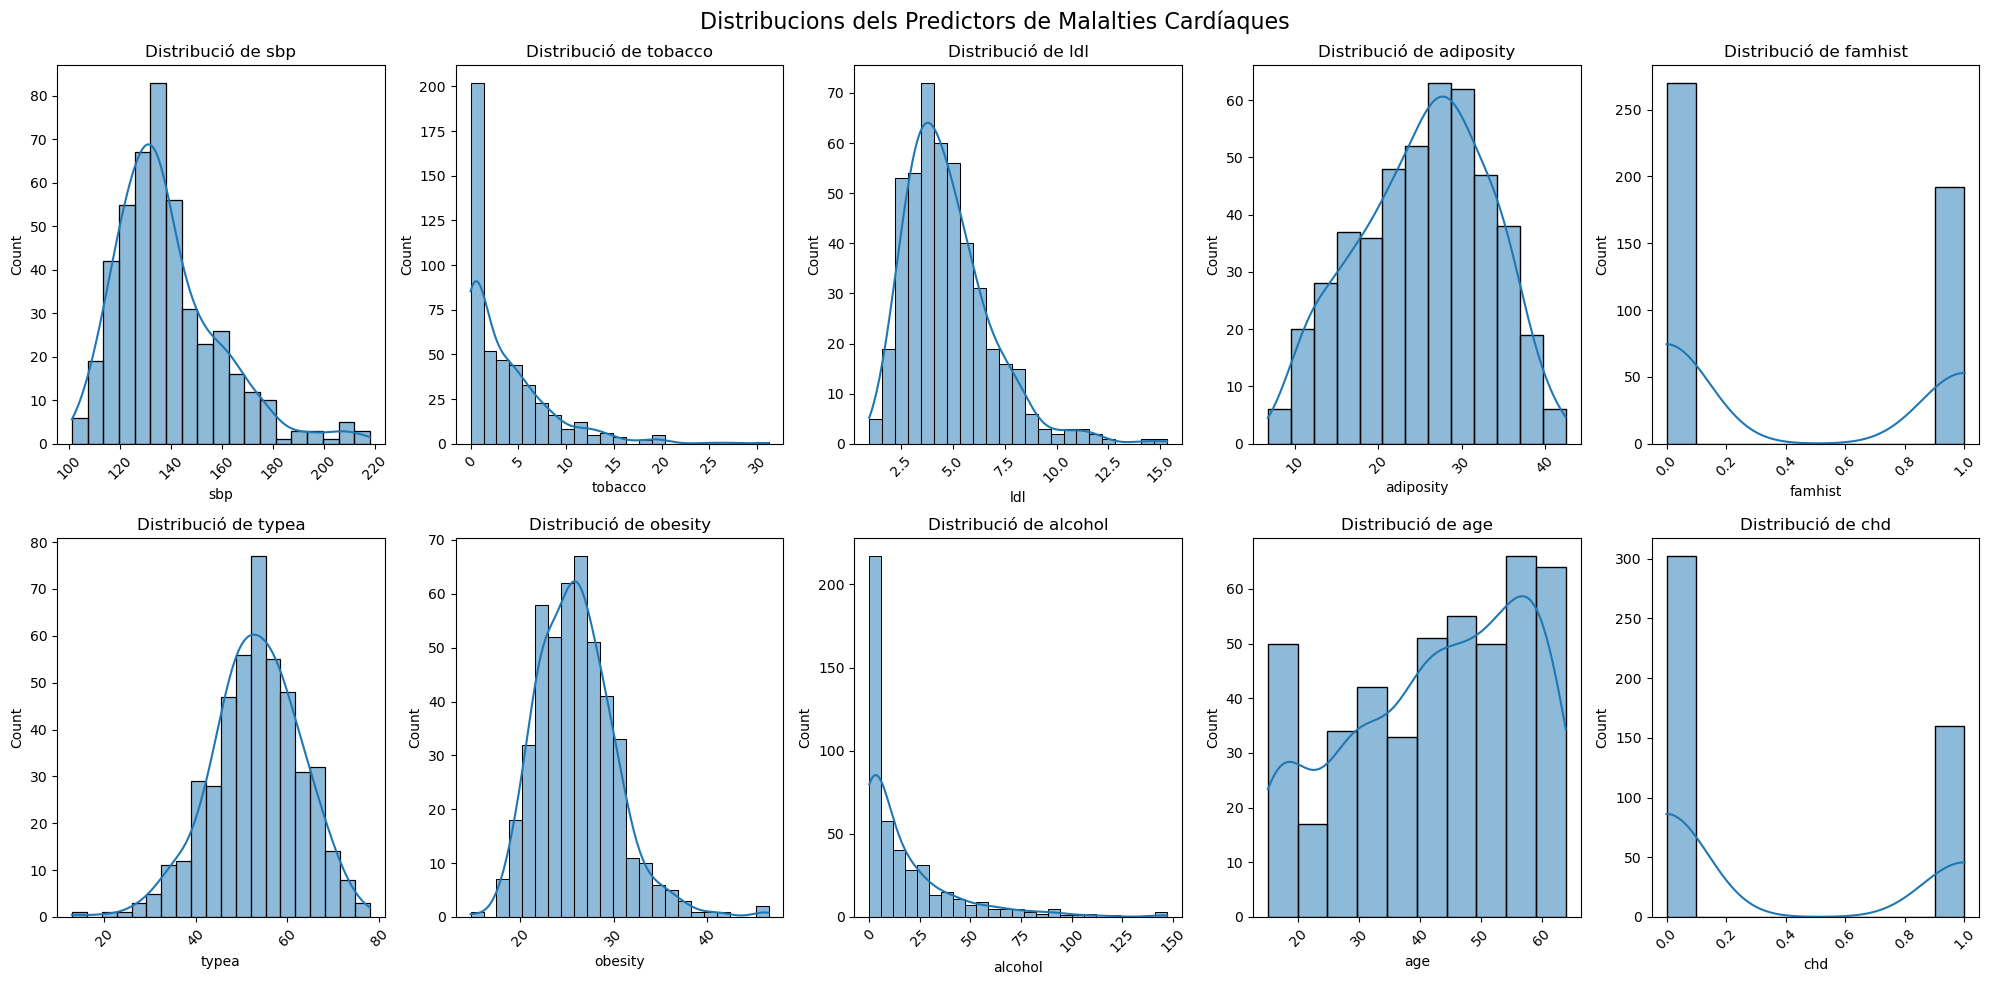

In [33]:
# Suposem que heart_data és el teu DataFrame
columns_to_plot = ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age', 'chd']

# Configurem el gràfic
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Distribucions dels Predictors de Malalties Cardíaques', fontsize=16)

# Aplanem els eixos per facilitar l'iteració
axes = axes.ravel()

# Bucle per cada columna per crear un gràfic
for i, col in enumerate(columns_to_plot):
    if heart_data[col].dtype == 'object':
        # Per a dades categòriques com 'famhist', usem countplot
        sns.countplot(data=heart_data, x=col, ax=axes[i])
    else:
        # Per a dades numèriques, usem histograma
        sns.histplot(data=heart_data, x=col, ax=axes[i], kde=True)

    # Rotem les etiquetes de l'eix X per una millor visibilitat si és necessari
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'Distribució de {col}')

# Ajustem el disseny per evitar solapaments
plt.tight_layout()

# Mostrem el gràfic
plt.show()


## <font color="red"><b>Exercici 5</b></font>

1. Expliqueu amb paraules (tres línies) el que enteneu per valor mitjà, mediana  i desviació estàndard i perquè en casos no gausians una descripció per percentils pot ser millor.
2. Expliqueu, a partir dels histogrames quina distribució de probabilitat és mes adient per cada variable {Gausiana, laplace, uniforme, binomial}.
3. **Optatiu:** Explicar el software i anotar si hi ha alguna instrucció nova que hagueu aprés.


## 3.2.2 Box Plot.
Resum de cinc cinc valors descriptius: mínim, primer quartil (Q1), mediana (Q2), tercer quartil (Q3) i màxim.

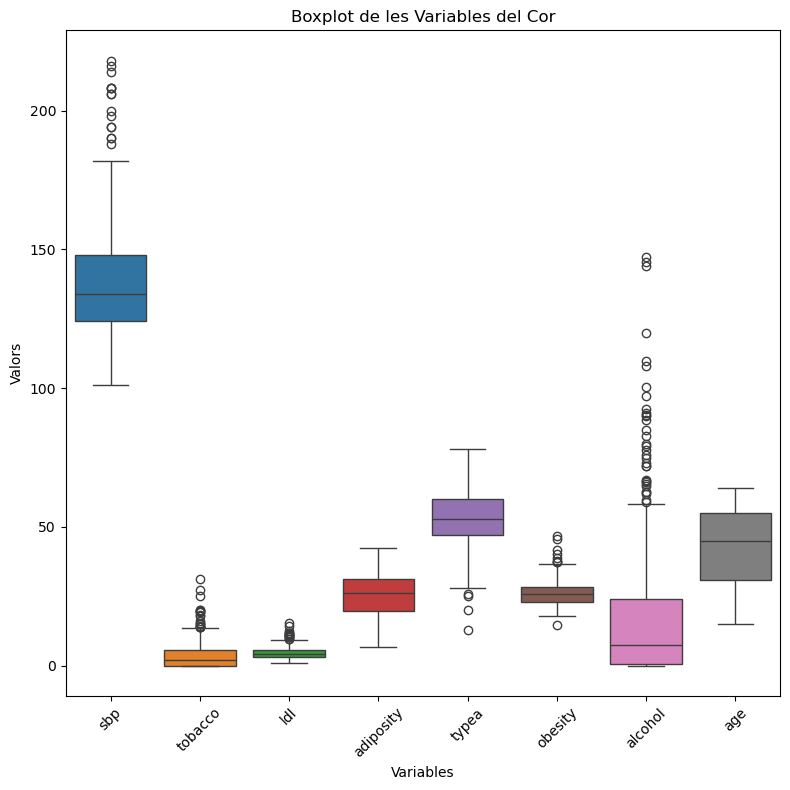

In [52]:
# Seleccionar les columnes per al boxplot
columns = ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']

# Crear una figura i un eix per a la visualització
plt.figure(figsize=(8, 8))

# Utilitzar Seaborn per fer un boxplot de les columnes seleccionades
sns.boxplot(data=heart_data[columns])

# Afegir títol i etiquetes als eixos
plt.title('Boxplot de les Variables del Cor')
plt.xlabel('Variables')
plt.ylabel('Valors')

# Rotar les etiquetes de l'eix X per millorar la llegibilitat
plt.xticks(rotation=45)

# Mostrar el gràfic
plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 6</b></font>
Objectiu d'aquest exercici: Entendre la informació proporcionada pel BoxPlot.
Recordar que serveix per donar una idea de les fites importants de la distribució de probabilitat de la variable.
1. Descrigui amb paraules per cada variable (una o dues linies), la informació que dóna el box plot. Què vol dir que una observació estigui a més de 1,5 vegades la desviació estàndard (valor extrem)? Com es veu que la distribució és asimètrica?
* Nota: $$P(Z > 1.5\sigma) = 1 - P(Z \le 1.5\sigma) \approx 1 - 0.9332 = 0.0668 \text{ (ó } 6.68\%)$$

In [35]:
# Desequilibris en les característiques categòriques
for col in [ 'famhist',  'chd']:
    print(f"Distribució de valors a {col}:  (percentatge)")
    print(f'{heart_data[col].value_counts(normalize=True).round(4)*100}')


Distribució de valors a famhist:  (percentatge)
famhist
0    58.44
1    41.56
Name: proportion, dtype: float64
Distribució de valors a chd:  (percentatge)
chd
0.0    65.37
1.0    34.63
Name: proportion, dtype: float64


## <font color="red"><b>Exercici 7</b></font>
**Conseqüència del desequilibri:**
1. Proposi un clasificador per **chd**  (*malaltia coronària del cor*) que necesita una línea de codi i proporciona un $65.37 \%$ d'encerts.

## 4.0. <font color="blue"><b>Recordatori:</b></font> Definició  de la Funció de Correlació

El coeficient de correlació entre dues variables $ X $ i $ Y $ és el coeficient de correlació de Pearson $ r $, que es calcula com:

$r_{X,Y} = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}$

On:
- $ n $ és el nombre de parells de puntuacions.
- $ X_i $ i $ Y_i $ són els punts de mostra individuals indexats amb $ i $.
- $ \bar{X} $ i $ \bar{Y} $ són les mitjanes de $ X $ i $ Y $, respectivament.

###  Interpretació del signe de la correlació:
- **$r_{X,Y} > 0$:** Les variables es mouen en la mateixa direcció (correlació positiva).
- **$r_{X,Y} < 0$:** Les variables es mouen en direccions oposades (correlació negativa).
- **$r_{X,Y} = 0$:** No hi ha cap relació lineal entre $X$ i $Y$.

- Exemple **$r_{X,Y} > 0$**:
<img src="ExempleCorrelacio.png" alt="ExempleCorrelacio" width="600"/> 
- Exemple **$r_{X,Y}  =  0$**:
<img src="ExempleCorrelacioNula.png" alt="Exemple Correlacio Nula" width="600"/> 

## <font color="red"><b>Exercici 8</b></font>

1. *Recordatori:* Descrigui amb paraules, a partir de la figura superior, els passos que es segueixen en el càlcul de la funció de correlació. Expliqui què pot significar que $(X_i - \bar{X})(Y_i - \bar{Y})$ tingui signes alternats i com això pot afectar el valor del coeficient de correlació $r_{X,Y}$.

###  4.1. Calcularem la matriu de correlació entre variables numériques.

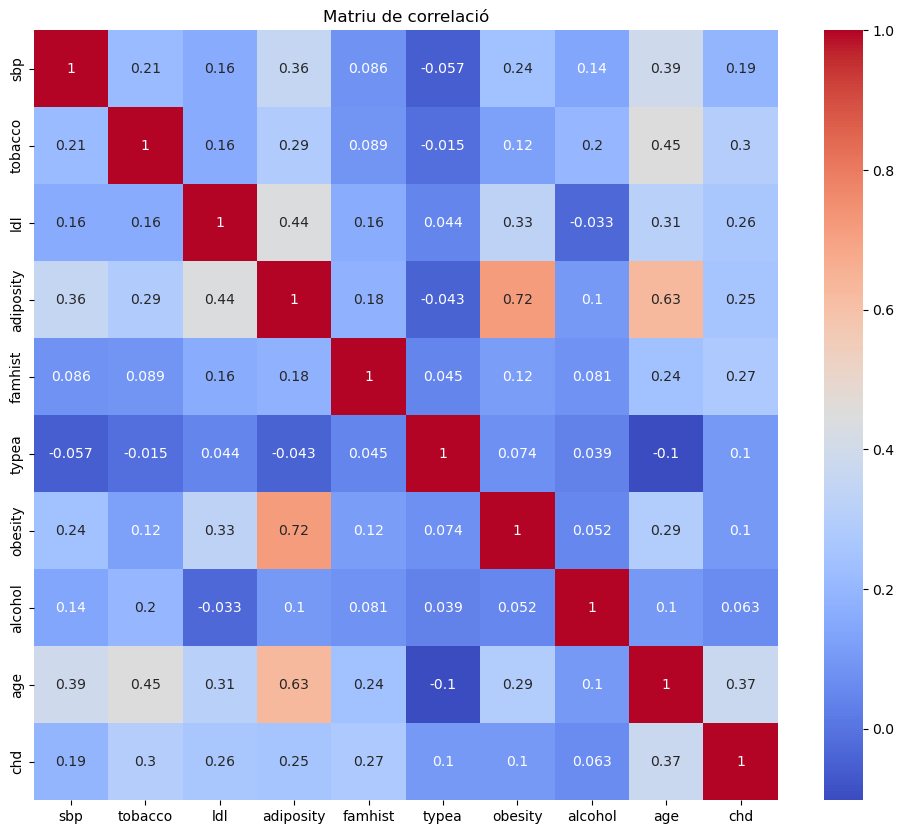

In [36]:
# Matriu de correlació
plt.figure(figsize=(12, 10))
corr_matrix = heart_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriu de correlació')
plt.show()


## <font color="red"><b>Exercici 9</b></font>
A partir de l'explicació del coeficient de correlació de Pearson, i el significat de les variables.
1. Expliqui *en dos linies* que significa que **chd** estigui correlada positivament amb el edat i tabac, i pràcticament incorrelada amb alcohol i obesitat.
2. Expliqui *en dos linies* que significa que el nivell de colesterol estigui negativament correlat amb el consum d'alchohol i positivament correlat amb tabac i pressió sangünea alta. Faci servir els diagrames de dispersió de l'explicació de $r_{X,Y}$


###  4.2. **Regressió no estandard**
####  Ranking de la correlació de les variables amb **chd**

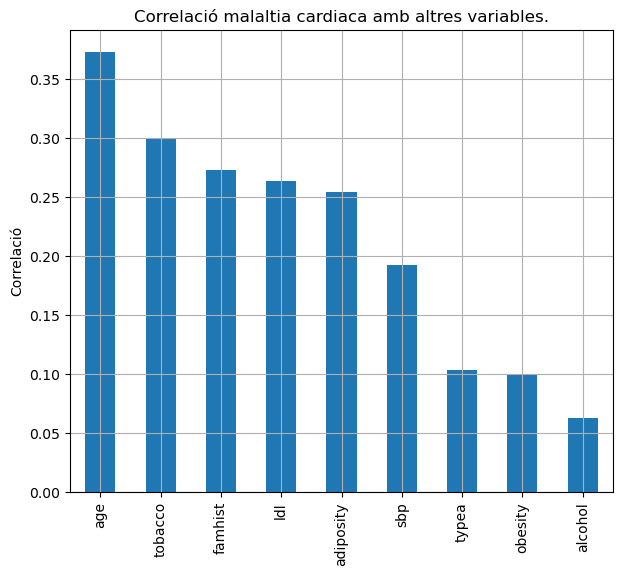

In [37]:
f, ax = plt.subplots(figsize=(7, 6))
ax = corr_matrix['chd'].iloc[:-1].sort_values(ascending=False).plot.bar()
plt.title('Correlació malaltia cardiaca amb altres variables.')
ax.xaxis.grid(True)
ax.yaxis.grid(True)
ax.set(ylabel="Correlació")
plt.show()


## <font color="red"><b>Exercici 10</b></font>
**Regressió no estandard.**
* **Nota:** Es fa servir molt sovint,  quan s'enten el problema de forma qualitativa i no es vol resoldre el problema de trobar els coeficients amb mínims quadràtics. **(!!!!)**
1. De forma qualitativa i amb coeficients pensats a partir de la figura anterior, proposar valors  $\beta_0 , \beta_1, \beta_2, \ldots, \beta_n $ per cada variable per obtenir un estimador qualitatiu del tipus:

   $$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_n X_n$$


###  4.3. Relació de comportament tipus "A" amb altres observacions.
#### Definició de Comportament de Tipus A
Aquest comportament està caracteritzat per:

- Ambició intensa,
- Impaciència, 
- Competitivitat, 
- Tendència a la hostilitat, 
- Pressió per acomplir moltes coses en poc temps 

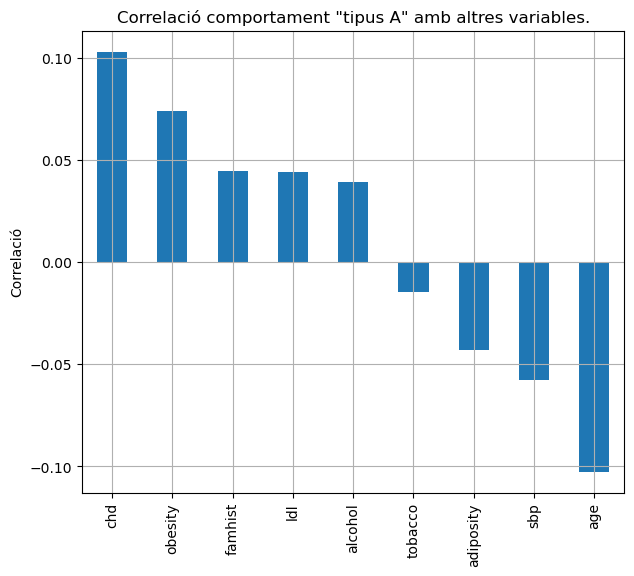

In [39]:
f, ax = plt.subplots(figsize=(7, 6))
ax = corr_matrix['typea'].sort_values(ascending=False).iloc[1:].plot.bar()
plt.title('Correlació comportament "tipus A" amb altres variables.')
ax.xaxis.grid(True)
ax.yaxis.grid(True)
ax.set(ylabel="Correlació")
plt.show()

## <font color="red"><b>Exercici 11</b></font>
1. Expliqui en un paràgraf el increment en risc donat per la personalitat en quan a diversos factors. Es un bon predictor de **chd**?, Hi ha component familiar?

###  4.4.  Explicació dels Diagrames de  dispersió.

Exemple: Edat vs. colesterol (ldl)
* Separar **variables que confonen** resultats, edat i colesterol amb malaltia cardiaca.

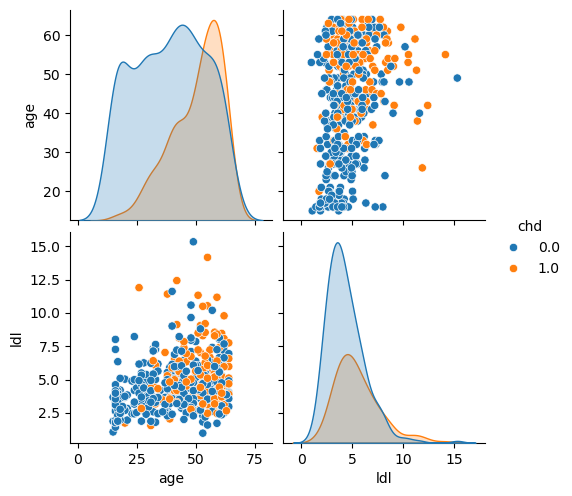

In [40]:
Columns = [ 'age','ldl']
sns.pairplot(heart_data,  hue = 'chd', vars=Columns)
plt.show()

##### Explicació del diagrama anterior
* Eix X 
L'eix X representa l'**edat dels pacients**. Els valors d'edat s'estenen al llarg de l'eix horitzontal, indicant el rang d'edats en el conjunt de dades. 

* Eix Y 
L'eix Y representa els **nivells de colesterol sèric** en mil·ligrams per decilitre (mg/dl). Els nivells de colesterol s'estenen al llarg de l'eix vertical, indicant el rang de nivells de colesterol presents en el conjunt de dades. 

* Punts de dades i segmentació per color
Cada punt del gràfic representa l'**edat i el nivell de colesterol d'un pacient** segmentat per presencia de malaltia chd =1 (taronja) o ausència chd = 0 (blau). 


###  4.4.1.  Diagrames de  dispersió de les variables mes correlades amb la malaltia caríaca 
a) tobacco, b) ldl (colesterol) c) adiposity, d) famhist, e) age
**Nota:** el diagrama de dispersió condicionat (colors diferents) per presècia/ausència de malaltia cardiaca, permet entendre com son de predictives les variales. Observar els histogrames 

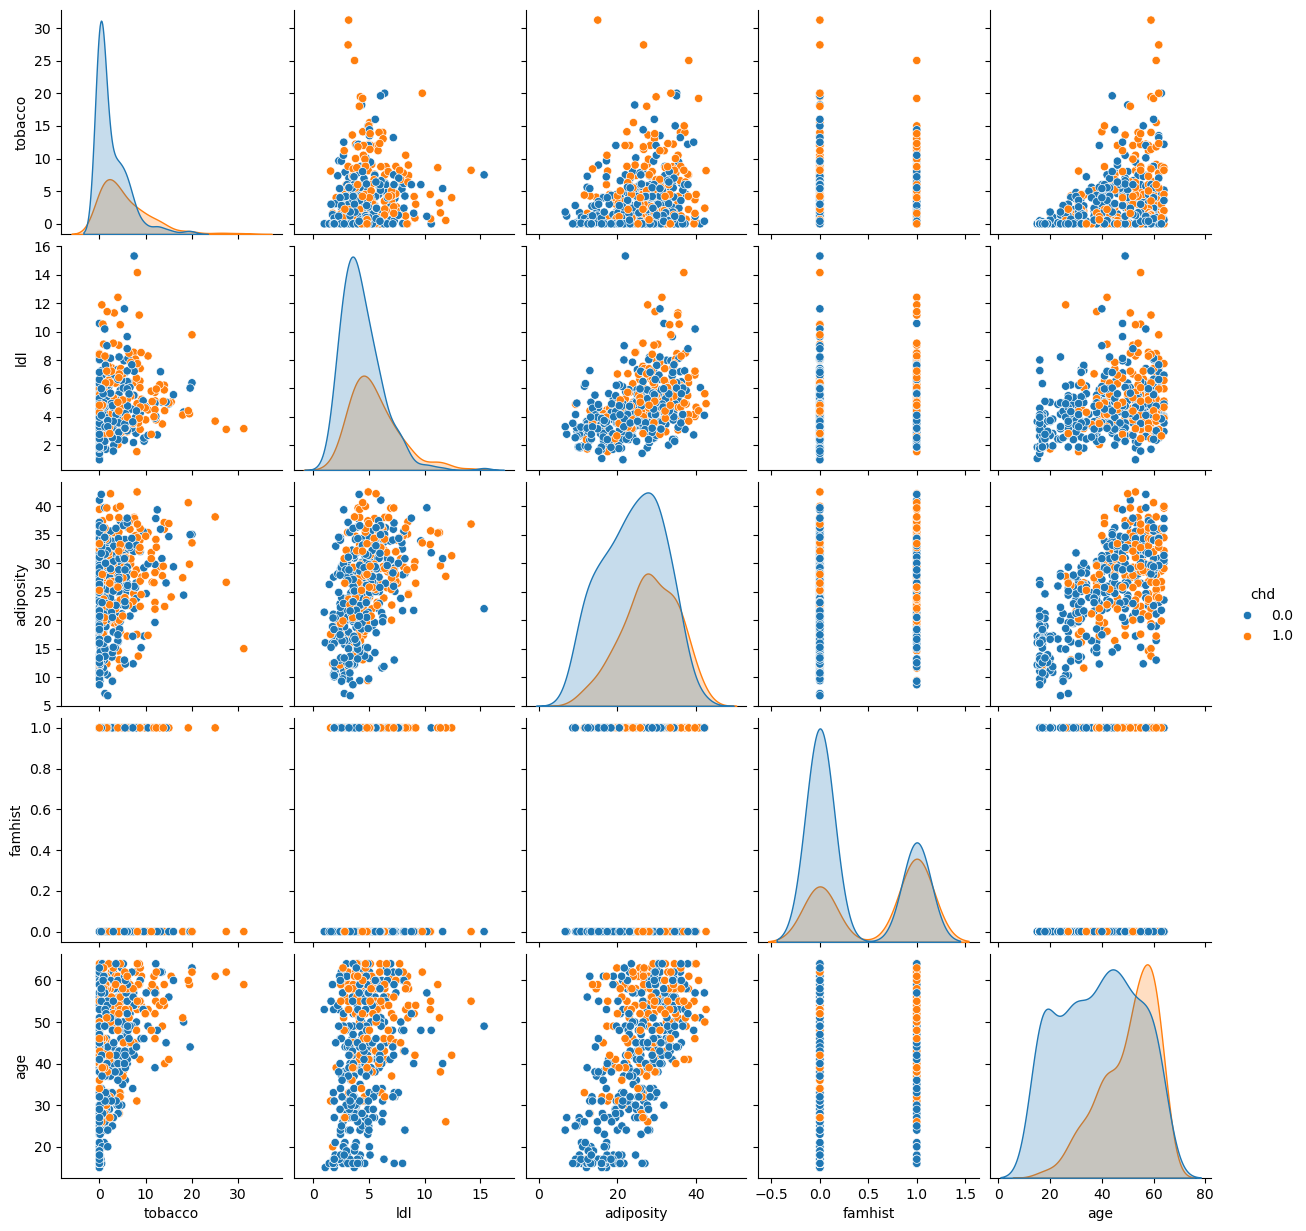

In [41]:
Columns = [ 'tobacco', 'ldl', 'adiposity', 'famhist',  'age']
sns.pairplot(heart_data,  hue = 'chd', vars=Columns)
plt.show()


## <font color="red"><b>Exercici 11</b></font>
1. Expliqui en un paràgraf com interpretar el diagrama anterior i com es pot utilitzar per entendre les relacions entre variables?
   Pista, observar que hi ha regions amb mes densitat de punts d'un color que altres.

# 5.0.  Creació del clasificador basat en regressió logistica. 

###  5.1. Justificació de la partició entre entrenament i test en Machine Learning
### Divisió de dades en ML

En **Machine Learning**, dividim les dades en **entrenament** i **test** per:

1. **Evitar sobreajustament** - Prevenir que el model aprengui patrons específics en lloc de generalitzar.
2. **Estimar rendiment** - Avaluar com el model funcionarà amb dades no vistes.
3. **Validar el model** - Comparar models i ajustar hiperparàmetres objectivament.
4. **Reduir biaixos** - Assegurar una avaluació sense inflar el rendiment.


In [43]:
Variables = ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity',
       'alcohol', 'age']
Objectiu = ['chd']
X =  heart_data[Variables].copy()
y = heart_data[Objectiu].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostra les dimensions dels conjunts resultants
print("X_train shape:", X_train.shape)  # Dimensions del conjunt d'entrenament (característiques)
print("X_test shape:", X_test.shape)    # Dimensions del conjunt de test (característiques)
print("y_train shape:", y_train.shape)  # Dimensions del conjunt d'entrenament (objectiu)
print("y_test shape:", y_test.shape)    # Dimensions del conjunt de test (objectiu)

X_train shape: (369, 9)
X_test shape: (93, 9)
y_train shape: (369, 1)
y_test shape: (93, 1)


### 5.2. Justificació de l'estandardització en Machine Learning

L'estandardització és important en ML per:

1. **Normalització** - Fer independent de l'escala (km, cm, kg, gm, etc.).
2. **Evitar biaixos** - Mitigar influències desiguals de característiques amb diferents escales.

La fórmula és:

$$z = \frac{x - \mu}{\sigma}$$

On:
- `x`: valor de la variable.
- `μ`: mitjana (entrenament).
- `σ`: desviació típica (entrenament).
- `z`: valor estandarditzat.

**Nota:** Calcular `μ` i `σ` només amb dades d'entrenament per evitar *data leakage*.

In [44]:
scaler = StandardScaler()
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
X_scaled = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [45]:
print("Valors abans d'estandaritzar")
pd.DataFrame(X_train,columns = X.columns).describe().round(1).iloc[1:]

Valors abans d'estandaritzar


,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age
mean,138.0,3.6,4.8,25.1,0.4,53.3,26.0,15.3,42.8
std,20.3,4.5,2.1,7.6,0.5,10.0,4.3,22.0,14.8
min,102.0,0.0,1.0,6.7,0.0,13.0,14.7,0.0,15.0
25%,124.0,0.0,3.3,19.5,0.0,47.0,22.9,0.5,31.0
50%,134.0,2.0,4.4,25.9,0.0,54.0,25.8,6.5,44.0
75%,148.0,5.5,5.6,30.7,1.0,60.0,28.4,21.6,56.0
max,216.0,31.2,15.3,42.5,1.0,78.0,46.6,147.2,64.0


In [46]:
print("Valors després d'estandaritzar")
pd.DataFrame(X_scaled,columns = X.columns).describe().round(1).iloc[1:]

Valors després d'estandaritzar


,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age
mean,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-1.8,-0.8,-1.8,-2.4,-0.8,-4.0,-2.6,-0.7,-1.9
25%,-0.7,-0.8,-0.7,-0.7,-0.8,-0.6,-0.7,-0.7,-0.8
50%,-0.2,-0.3,-0.2,0.1,-0.8,0.1,-0.1,-0.4,0.1
75%,0.5,0.4,0.4,0.7,1.2,0.7,0.5,0.3,0.9
max,3.9,6.1,5.0,2.3,1.2,2.5,4.8,6.0,1.4


## <font color="red"><b>Exercici 12</b></font>
1. Per aclarir idees, expliqui un parell de linies,
    1. Per què s'ha fet la divisió entre train i test?
    2. Les diferències entre estandaritzar i no estandaritzar en quan a valor mig, desviació estandard, i rang interquantil.

## 5.3. Estimació dels paràmetres de la regressió logística.

1. log_reg = LogisticRegression(max_iter=1000): inicialitza un model de regressió logística amb un màxim de 1000 iteracions per a la convergència.
2. log_reg.fit(X_train, y_train.values.ravel()): entrena el model amb les dades d'entrenament `X_train` i les etiquetes `y_train` (aplana les etiquetes amb `.ravel()`).
3. y_pred = log_reg.predict(X_test): Futilitza el model entrenat per predir els resultats per a les dades de test `X_test` i asigna aquestes prediccions en `y_pred`.

In [47]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train.values.ravel())

y_pred = log_reg.predict(X_test)


##### comparació de la referència y_test amb la predicció y_pred

In [48]:
pd.DataFrame({'y_test':y_test.values.ravel(), 'y_pred':y_pred}).T

,0,1,2,3,4,5,6,7,8,9,...,83,84,85,86,87,88,89,90,91,92
y_test,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
y_pred,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## 5.4. Avaluació del Model

## Paràmetres d'Avaluació de la qualitat del model

### 1. Precisió (Precision)
**Definició:** La precisió és la relació entre les instàncies predites correctament i el total d'instàncies en el conjunt de dades. Mesura l'efectivitat general del model.

$$\text{Precisió} = \frac{\text{VP} + \text{VN}}{\text{VP} + \text{VN} + \text{FP} + \text{FN}}$$

On:
- VP = Veritables Positius
- VN = Veritables Negatius
- FP = Falsos Positius
- FN = Falsos Negatius

### 2. Sensibilitat (Recall)
**Definició:** La sensibilitat, també coneguda com a recall, és la relació entre les observacions positives predites correctament i tots els positius reals. Mesura la capacitat del model per identificar instàncies positives.

$$\text{Sensibilitat} = \frac{\text{VP}}{\text{VP} + \text{FN}}$$

On:
- VP = Veritables Positius
- FN = Falsos Negatius

### 3. Puntuació F1 (F1-Score)
**Definició:** La puntuació F1 és la mitjana harmònica de l'exactitud i la sensibilitat. Proporciona un equilibri entre les dues mètriques, especialment en conjunts de dades desequilibrats.

$$\text{Puntuació F1} = 2 \times \frac{\text{Exactitud} \times \text{Sensibilitat}}{\text{Exactitud} + \text{Sensibilitat}}$$

### 4. Suport (Support):

**Definició:** El suport és el nombre d'ocurrències de cada classe en el conjunt de dades de test. Reflecteix la quantitat de dades disponibles per a cada classe per avaluar el rendiment del model.
$$Suport = TP + FN$$

On:
- **TP**: Nombre d'instàncies que són de la classe i han estat correctament predites com a tals.
- **FN**: Nombre d'instàncies de la classe que han estat incorrectament predites com a no pertanyents a la classe.


In [49]:
print("Informe de Classificació:")
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.iloc[:-3]

Informe de Classificació:


,precision,recall,f1-score,support
0.0,0.776119,0.881356,0.825397,59.0
1.0,0.730769,0.558824,0.633333,34.0


## <font color="red"><b>Exercici 13</b></font>
1. En base a les definicions anteriors donar una explicació en un paràgraf del informe de classificació. Valori les prestacions del classificador.

###  Matriu de Confusió
**Definició:** Una matriu de confusió és una taula que s'utilitza per avaluar el rendiment d'un model de classificació. Resumeix el recompte de prediccions de veritables positius, veritables negatius, falsos positius i falsos negatius.

$$\begin{array}{|c|c|c|} \hline  & \text{Predicció Positiva} & \text{Predicció Negativa} \\ \hline \text{Real Positiu} & \text{VP} & \text{FN} \\ \hline \text{Real Negatiu} & \text{FP} & \text{VN} \\ \hline \end{array}$$

In [50]:
# Confusion matrix
print("Matriu de Confusió:")
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, 
                     index=['Real Positiu', 'Real Negatiu'], 
                     columns=['Predicció Positiva', 'Predicció Negativa'])

df_cm

Matriu de Confusió:


,Predicció Positiva,Predicció Negativa
Real Positiu,52,7
Real Negatiu,15,19


## <font color="red"><b>Exercici 14</b></font>
1. En base a les definicions anteriors donar una explicació en un paràgraf de la Matriu de Confusió. Valori les prestacions del classificador.

## <font color="blue"><b>Avançat i optatiu </b></font>

### Definició de la Corba ROC (Receiver Operating Characteristic)

La **Corba de Característica de Funcionament del Receptor (ROC)** és una eina gràfica utilitzada per avaluar la capacitat d'un classificador binari de discriminar entre classes positives i negatives. La corba es construeix traçant la **Taxa de Veritables Positius (TPR)** contra la **Taxa de Falsos Positius (FPR)** a diferents nivells de llindar de classificació.

- **Taxa de Veritables Positius (TPR)**: També coneguda com a **sensibilitat o recall**, és la proporció d'instàncies positives que han estat correctament identificades. 
  - **Fórmula:** TPR = VP / (VP + FN), on VP és Veritables Positius i FN és Falsos Negatius.

- **Taxa de Falsos Positius (FPR)**: És la proporció d'instàncies negatives que han estat incorrectament classificades com a positives.
  - **Fórmula:** FPR = FP / (FP + VN), on FP és Falsos Positius i VN és Veritables Negatius.

### Com interpretar la Corba ROC:

- **Taxa de Falsos Positius (FPR)**: Representa la taxa d'error de tipus I (falsos positius). Com més baixa sigui aquesta taxa, millor és el model a l'hora de no classificar falsament negatives com a positives.

- **Taxa de Veritables Positius (TPR)**: Representa la sensibilitat del model. Una TPR alta indica que el model és bo per identificar veritables positius.

- **Línia de referència**: La línia de punts (o línia diagonal) representa un classificador aleatori. Si la corba ROC del model està per sobre d'aquesta línia, el model té una capacitat de predicció millor que l'atzar.

- **Àrea sota la Corba (AUC)**: 
  - Un AUC de 1 indica un classificador perfecte.
  - Un AUC de 0.5 suggereix que el model està predint a l'atzar (equivalent a la línia diagonal).
  - Un AUC menys de 0.5 implicaria que el model està predint pitjor que l'atzar.

Quan més s'apropa la corba ROC a l'eix superior esquerre del gràfic, més bo és el model, ja que això significa que és capaç d'aconseguir una alta taxa de veritables positius amb una taxa de falsos positius baixa. L'AUC proporciona una mesura agregada de la rendiment del model a través de tots els possibles punts de tall.

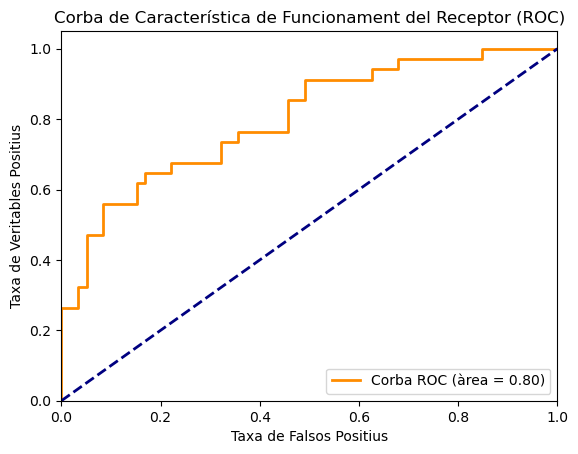

In [51]:
from sklearn.metrics import roc_curve, auc


# Obtenim les probabilitats per a la classe 1
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Calculem la corba ROC i l'àrea ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Traçem la corba ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Corba ROC (àrea = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positius')
plt.ylabel('Taxa de Veritables Positius')
plt.title('Corba de Característica de Funcionament del Receptor (ROC)')
plt.legend(loc="lower right")
plt.show()

## <font color="red"><b>Exercici 15</b></font>
1. En base a les definicions anteriors donar una explicació en un paràgraf de la corba ROC. Valori les prestacions del classificador.

## <font color="Blue"><b>Informe Final i Recomanacions</b></font>
1. Informe on es relaciona la informació obtinguda amb l'estudi fet amb l'EDA amb els resultats obtinguts pel mètode de machine learning.

2. Recomanacions per millorar el sistema i implementar-lo.